# FLAIR WFST tools

This notebook contains an overview of the FLAIR WFST tools and their usage, including an introduction to WFSTs.

## Introduction

Some basic questions:

- What is a (W)FST?
- What is it good for?
- I'm sold!  How do I make one and how to I use it?

### Setup

Let's start by importing the `FST` class from the `pyfoma` library that we use, and some utility functions from this package:

In [5]:
from pyfoma import FST

### What is a FST?

You can read the [https://en.wikipedia.org/wiki/Finite-state_transducer](technical and formal definition), but for our purposes, it's most useful to think of an FST as a kind of dictionary.  That is, it is a particular way for a computer to represent a collection of *pairs* of words.

An FST (finite-state transducer) is a particular case of a finite-state machine (no, not [that](https://en.wikipedia.org/wiki/Flying_Spaghetti_Monster) kind of FSM).  There is also a simpler form of FST which we refer to as an *acceptor* or FSA.  In this case, it's also like a dictionary except that it is just a collection of individual words.

When you add the "W" to it to get a *weighted* FST, it represents not just a collection of pairs of words, but also a numerical value associated with each pair of words.  We aren't going to talk about that much here, but keep it in mind for later.

Let's look at some examples.  First, the simple case of an FSA, which is just a list of words in a particular form:

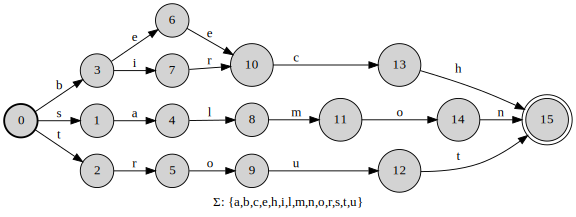

In [18]:
fsa = FST.from_strings(["salmon", "trout", "birch", "beech"])
fsa.view()

We can see that this FSA *recognizes* words which are in the collection, and only these words.  This set of words is called the *language* of the FSA:

In [22]:
list(fsa.apply("birch"))

['birch']

In [23]:
list(fsa.apply("salmon"))

['salmon']

In [24]:
list(fsa.apply("spruce"))

[]

Now let's consider an FST, which, as mentioned earlier, is a set of *pairs*.  For example, we could imagine an FST for an English-French dictionary:

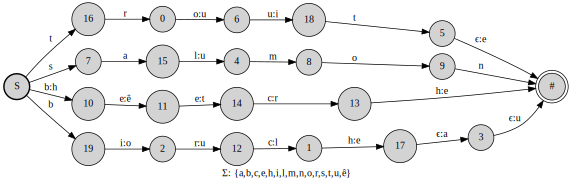

In [34]:
fst = FST.rlg({"S": [
    (("salmon", "saumon"), "#"),
    (("trout", "truite"), "#"),
    (("birch", "bouleau"), "#"),
    (("beech", "hêtre"), "#"),
]}, "S")
fst.view()

What can we do with this?  We can, obviously, print out all of the pairs of words that it recognizes:

In [38]:
list(fst.words())

[(0.0, [('b', 'h'), ('e', 'ê'), ('e', 't'), ('c', 'r'), ('h', 'e')]),
 (0.0, [('s',), ('a',), ('l', 'u'), ('m',), ('o',), ('n',)]),
 (0.0, [('t',), ('r',), ('o', 'u'), ('u', 'i'), ('t',), ('', 'e')]),
 (0.0,
  [('b',),
   ('i', 'o'),
   ('r', 'u'),
   ('c', 'l'),
   ('h', 'e'),
   ('', 'a'),
   ('', 'u')])]

But more interestingly, it also works as a *mapping* from one word to the other in each pair, so in this case you can use it to *translate* words, just like looking up in a dictionary, and more importantly, this works in both directions (looking up English to get French, or French to get English):

In [36]:
list(fst.apply("beech"))

['hêtre']

In [37]:
list(fst.analyze("hêtre"))

['beech']

### What is it good for?

Spolier alert: somewhat more than absolutely nothing!

The "translation" example above isn't particularly realistic (that's not how machine translation works), but what is realistic is using an FSA to store a list of words, or an FST to store a mapping of a list of words to the *pronunciation* of each word.  This is very useful for speech recognition, for instance.  But also for language learning!  For example:

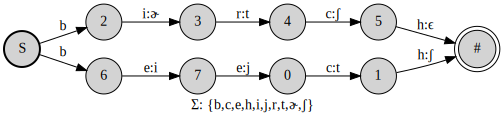

In [41]:
fst = FST.rlg({"S": [
    (("birch", "bɚtʃ"), "#"),
    (("beech", "bijtʃ"), "#"),
]}, "S")
fst.view()

(you'll notice that the FST doesn't necessary make "logical" choices of which letters to map to which IPA symbols, because it doesn't actually know anything about phonology)

Why would you do this instead of just storing this list or mapping in your favorite data structure in your favorite programming language?  Or, you know, on paper, like the good old days?

This is where it gets a bit confusing.  Even though the word "finite" is in the acronym, an FST can actually represent, with its finite states, an *infinite* number of different (pairs of) words.  And as all good linguists know, human languges generally contain an infinite (or at least extremely large) number of possible words, because humans are good at:

- inventing new words based on existing words and well-known patterns or rules (*derivation*)
- recognizing a large number of words as actualy being the "same" word, just in a different context, tense, person, etc, etc (*conjugation*, *declension*, or as linguists say, *inflection*)

And as *you* probably know, polysynthetic languages, like most of the Indigenous languages of the Americas, have a particularly large number of words that are not only possible, but commonly used.

So if you're going to make a dictionary (or a speech recognizer) for your language, it's really, really, really hard to just make a list of all the words.